# PHẦN 3: ĐÁNH GIÁ MÔ HÌNH TRÍCH XUẤT ĐẶC TRƯNG (ENCODER)
**Mục tiêu:** Phần này trình bày các thí nghiệm nhằm đánh giá chất lượng của mạng **ResNet-101** (đóng vai trò là Encoder trong bài toán Image Captioning) so với các kiến trúc CNN phổ biến khác (VGG-16, ShuffleNet-V2) và phương pháp trích xuất đặc trưng truyền thống (HOG).

## 3.1. So sánh hiệu suất giữa các mô hình CNN
Các mô hình đều sử dụng trọng số pre-trained từ ImageNet. Mô hình VGG-16 và ShuffleNet-V2 không sử dụng hiệu chỉnh L2 hay Dropout bổ sung như ResNet-101 do cấu trúc đặc thù của chúng.

,Mô hình,Số tham số (M),Top-1 Accuracy (%),Top-5 Accuracy (%)
0,ResNet-101,44.6,61.306,90.306
1,VGG-16,138.0,57.305,88.276
2,ShuffleNet-V2,1.3,52.747,85.111


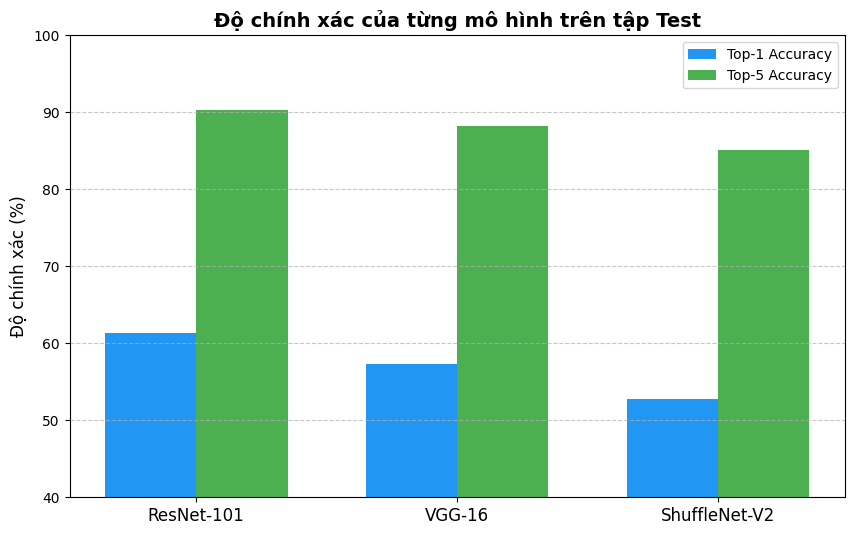

👉 Kết luận: ResNet-101 là mô hình vượt trội nhất cho bài toán phân loại đối tượng ảnh trong phạm vi thử nghiệm, với sự cân bằng tốt giữa số lượng tham số và độ chính xác.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Tạo DataFrame từ số liệu báo cáo
data = {
    'Mô hình': ['ResNet-101', 'VGG-16', 'ShuffleNet-V2'],
    'Số tham số (M)': [44.6, 138.0, 1.3],
    'Top-1 Accuracy (%)': [61.306, 57.305, 52.747],
    'Top-5 Accuracy (%)': [90.306, 88.276, 85.111]
}
df = pd.DataFrame(data)
display(df)

# 2. Vẽ biểu đồ so sánh độ chính xác
x = np.arange(len(df['Mô hình']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, df['Top-1 Accuracy (%)'], width, label='Top-1 Accuracy', color='#2196F3')
rects2 = ax.bar(x + width/2, df['Top-5 Accuracy (%)'], width, label='Top-5 Accuracy', color='#4CAF50')

ax.set_ylabel('Độ chính xác (%)', fontsize=12)
ax.set_title('Độ chính xác của từng mô hình trên tập Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Mô hình'], fontsize=12)
ax.legend()
ax.set_ylim(40, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print("👉 Kết luận: ResNet-101 là mô hình vượt trội nhất cho bài toán phân loại đối tượng ảnh trong phạm vi thử nghiệm, với sự cân bằng tốt giữa số lượng tham số và độ chính xác.")

## 3.2. Trích xuất đặc trưng

### 3.2.1. Trích xuất đặc trưng từ ResNet-101
Báo cáo sử dụng kết quả đầu ra của lớp `conv5_x` làm đặc trưng của ảnh, sau đó trải phẳng (flatten) thành một vector. Vector này có các đặc tính sau:
* **Số chiều:** Đầu ra của lớp `conv5_x` là một tensor có kích thước $2048 \times 8 \times 8$ (gồm 2048 feature maps kích thước $8 \times 8$). Sau khi trải phẳng, kích thước vector là 131.072 chiều.
* **Thông tin lưu trữ:** Vector lưu trữ thông tin về các đặc trưng cục bộ trong ảnh (ví dụ: phần đầu, phần bụng của con ngựa,...).

[*] Kích thước Tensor đầu ra từ conv5_x: torch.Size([1, 2048, 8, 8]) (Batch, Channels, Height, Width)


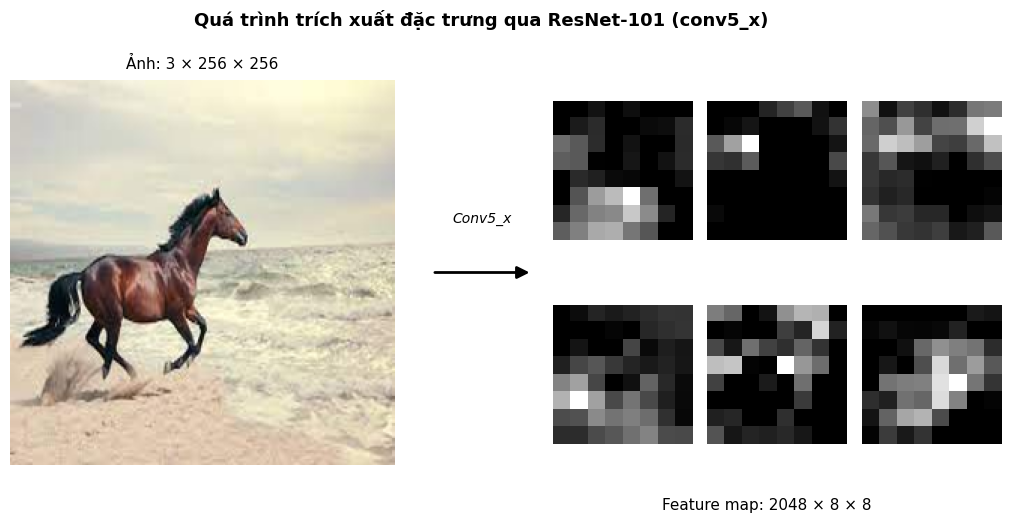

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from PIL import Image

# 1. Tải mô hình ResNet101
resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
resnet.eval()

# Bóc tách để lấy đầu ra tới lớp conv5_x (layer4 trong PyTorch)
modules = list(resnet.children())[:-2]
feature_extractor = torch.nn.Sequential(*modules)

img_path = '../data/coco/horse_sample.jpg'

def visualize_feature_maps(img_path):
    try:
        # Đọc và xử lý ảnh
        img = Image.open(img_path).convert('RGB')
        transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        img_tensor = transform(img).unsqueeze(0)

        # Trích xuất đặc trưng
        with torch.no_grad():
            features = feature_extractor(img_tensor)

        print(f"[*] Kích thước Tensor đầu ra từ conv5_x: {features.shape} (Batch, Channels, Height, Width)")

        # ----------------------------------------------------------------
        # Layout: [ảnh gốc] [mũi tên] [3 feature maps] [3 feature maps]
        # width_ratios:  3       0.8        1    1    1
        # ----------------------------------------------------------------
        fig = plt.figure(figsize=(13, 5))
        gs = gridspec.GridSpec(
            2, 5,
            width_ratios=[3, 0.8, 1, 1, 1],
            wspace=0.08,
            hspace=0.12
        )

        # --- Cột 0: Ảnh gốc (chiếm 2 hàng) ---
        ax_img = fig.add_subplot(gs[:, 0])
        ax_img.imshow(img.resize((256, 256)))
        ax_img.set_title('Ảnh: 3 × 256 × 256', fontsize=11, pad=8)
        ax_img.axis('off')

        # --- Cột 1: Mũi tên + nhãn Conv5_x (chiếm 2 hàng) ---
        ax_arrow = fig.add_subplot(gs[:, 1])
        ax_arrow.set_xlim(0, 1)
        ax_arrow.set_ylim(0, 1)
        ax_arrow.axis('off')

        # Vẽ mũi tên nằm ngang chính giữa cột
        arrow = FancyArrowPatch(
            (0.05, 0.5), (0.95, 0.5),
            transform=ax_arrow.transAxes,
            arrowstyle='-|>',
            mutation_scale=18,
            linewidth=2,
            color='black'
        )
        ax_arrow.add_patch(arrow)

        # Nhãn phía trên mũi tên
        ax_arrow.text(
            0.5, 0.62, 'Conv5_x',
            transform=ax_arrow.transAxes,
            ha='center', va='bottom',
            fontsize=10, fontstyle='italic'
        )

        # --- Cột 2-4, hàng 0-1: 6 Feature maps ---
        for i in range(6):
            row = i // 3          # 0 hoặc 1
            col = (i % 3) + 2     # 2, 3, 4
            ax_feat = fig.add_subplot(gs[row, col])
            ax_feat.imshow(features[0, i, :, :].numpy(), cmap='gray')
            ax_feat.axis('off')

        # Chú thích chung phía dưới vùng feature map
        # Dùng fig.text để đặt tự do, không bị ảnh hưởng bởi layout
        fig.text(
            0.72, 0.02,
            'Feature map: 2048 × 8 × 8',
            ha='center', fontsize=11
        )

        plt.suptitle('Quá trình trích xuất đặc trưng qua ResNet-101 (conv5_x)', 
                     fontsize=13, fontweight='bold', y=1.02)
        plt.savefig('feature_map_visualization.png', bbox_inches='tight', dpi=150)
        plt.show()

    except FileNotFoundError:
        print(f"❌ Không tìm thấy ảnh tại: {img_path}")
        print("💡 Vui lòng copy một bức ảnh vào thư mục tương ứng và sửa lại biến img_path!")

# Chạy thử hàm
visualize_feature_maps(img_path)

### 3.2.2. Trích xuất đặc trưng bằng HOG (Histogram of Oriented Gradients)

Bên cạnh các đặc trưng ngữ nghĩa từ mạng học sâu, đồ án sử dụng thuật toán **HOG** như một phương pháp trích xuất đặc trưng truyền thống để làm cơ sở đối chứng. HOG hoạt động bằng cách tính toán sự phân bố của các hướng gradient trong các vùng cục bộ của hình ảnh.

**Cấu hình thực nghiệm:**
Để đảm bảo tính tương đồng khi so sánh với ResNet-101, các tham số HOG được thiết lập như sau:
* **Kích thước đầu vào:** Ảnh xám (Grayscale) $256 \times 256$ pixel.
* **Pixels per Cell:** $8 \times 8$ (Mỗi ô cơ bản để tính Histogram).
* **Cells per Block:** $2 \times 2$ (Vùng chuẩn hóa để giảm ảnh hưởng của ánh sáng).
* **Orientations (Bins):** 9 hướng (Chia góc $180^\circ$ thành 9 khoảng).

In [3]:
import numpy as np
from skimage.feature import hog
from PIL import Image

def get_hog_features(img_path, visualize=False):
    """Trích xuất vector đặc trưng HOG theo đúng tham số báo cáo"""
    # Đọc ảnh và tiền xử lý (Grayscale + Resize)
    img = Image.open(img_path).convert('L').resize((256, 256), Image.Resampling.LANCZOS)
    img_array = np.array(img)
    
    # Thực thi HOG
    # Trả về vector 1D: (31 blocks x 31 blocks) * (2x2 cells/block) * (9 bins) = 34,596 chiều
    return hog(img_array, 
               orientations=9, 
               pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), 
               block_norm='L2-Hys', 
               visualize=visualize, 
               feature_vector=True)

def cos_sim_numpy(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Đường dẫn ảnh (bạn nhớ đảm bảo file tồn tại)
img_horse1 = '../data/coco/horse_sample.jpg'
img_horse2 = '../data/coco/horse2.jpg'
img_man    = '../data/coco/man_laughing.jpg'

print("[*] Đang tính toán đặc trưng HOG thực tế...")

# Tính toán vector
hog_v1 = get_hog_features(img_horse1) # Ảnh ngựa 1
hog_v2 = get_hog_features(img_horse2) # Ảnh ngựa 2
hog_v3 = get_hog_features(img_man)    # Ảnh người cười

# Tính Similarity
sim_hog_12 = cos_sim_numpy(hog_v1, hog_v2)
sim_hog_13 = cos_sim_numpy(hog_v1, hog_v3)

print(f"\n📈 KẾT QUẢ TÍNH TOÁN HOG TRỰC TIẾP:")
print(f"➤ HoG similarity (Ngựa - Ngựa): {sim_hog_12:.7f}")
print(f"➤ HoG similarity (Ngựa - Người cười): {sim_hog_13:.7f}")

[*] Đang tính toán đặc trưng HOG thực tế...

📈 KẾT QUẢ TÍNH TOÁN HOG TRỰC TIẾP:
➤ HoG similarity (Ngựa - Ngựa): 0.6566005
➤ HoG similarity (Ngựa - Người cười): 0.5268165


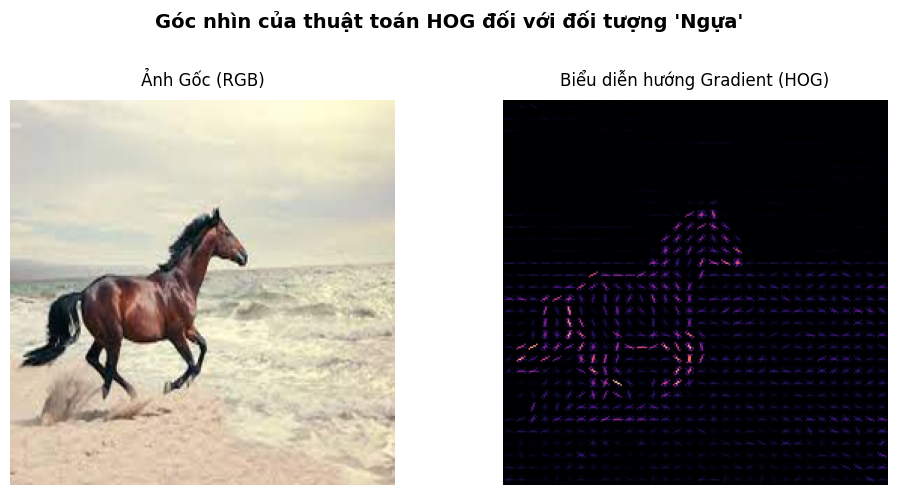

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from PIL import Image

# 1. KHAI BÁO LẠI HÀM (Để tránh lỗi khi chạy lại từ đầu)
def get_hog_vector(img_path, visualize=False):
    """Hàm trích xuất HOG có hỗ trợ trả về ảnh visualize"""
    img = Image.open(img_path).convert('L').resize((256, 256), Image.Resampling.LANCZOS)
    img_array = np.array(img)
    return hog(img_array, 
               orientations=9, 
               pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), 
               block_norm='L2-Hys', 
               visualize=visualize, 
               feature_vector=True)

# Đảm bảo đường dẫn ảnh đã tồn tại
img_horse1 = '../data/coco/horse_sample.jpg'

# 2. HÀM TRỰC QUAN HÓA CỦA BẠN
def visualize_hog_perspective(img_path, title=""):
    try:
        # Lấy cả vector và ảnh biểu diễn
        _, hog_image = get_hog_vector(img_path, visualize=True)
        img_original = Image.open(img_path).convert('RGB').resize((256, 256))

        # Cấu hình giao diện 2 khung hình
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

        # Ảnh gốc
        ax1.imshow(img_original)
        ax1.set_title("Ảnh Gốc (RGB)", fontsize=12, pad=10)
        ax1.axis('off')

        # Ảnh HOG
        ax2.imshow(hog_image, cmap='magma')
        ax2.set_title("Biểu diễn hướng Gradient (HOG)", fontsize=12, pad=10)
        ax2.axis('off')

        # Dùng tight_layout với rect để nhường chỗ cho suptitle phía trên
        fig.suptitle(title, fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()

    except Exception as e:
        print(f"⚠️ Lỗi hiển thị: {e}")

# Trực quan hóa góc nhìn của HOG trên ảnh con ngựa
visualize_hog_perspective(img_horse1, "Góc nhìn của thuật toán HOG đối với đối tượng 'Ngựa'")

## 3.3. So sánh hiệu suất trích xuất đặc trưng (ResNet-101 vs. HOG)

Trong phần này, đồ án tiến hành đối chiếu kết quả định lượng thu được từ hai phương pháp trích xuất đặc trưng. Mục tiêu là làm rõ sự khác biệt giữa **đặc trưng hướng Gradient (HOG)** và **đặc trưng ngữ nghĩa (ResNet-101)** thông qua chỉ số độ tương đồng Cosine (Cosine Similarity).

**Các kịch bản thử nghiệm:**
1. **Cặp ảnh cùng chủ đề (Ngựa - Ngựa):** Kiểm tra khả năng nhận diện các đối tượng tương đồng.
2. **Cặp ảnh khác chủ đề (Ngựa - Người cười):** Kiểm tra khả năng phân biệt giữa các lớp đối tượng khác nhau.

In [5]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from skimage.feature import hog

# Định nghĩa Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. HÀM TRÍCH XUẤT ĐẶC TRƯNG
# ==========================================
def get_resnet_vector(img_path, model):
    """Trích xuất vector 2048 chiều bằng ResNet101"""
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        feature_vector = model(img_tensor) 
    return feature_vector.flatten()

def get_hog_vector(img_path):
    """Trích xuất vector đặc trưng HOG"""
    img = Image.open(img_path).convert('L').resize((256, 256), Image.Resampling.LANCZOS)
    img_array = np.array(img)
    features = hog(img_array, 
                   orientations=9, 
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), 
                   block_norm='L2-Hys', 
                   visualize=False, 
                   feature_vector=True)
    return features

def cos_sim_numpy(v1, v2):
    """Tính Cosine Similarity cho vector Numpy (HOG)"""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# ==========================================
# 2. KHỞI TẠO MÔ HÌNH VÀ TÍNH TOÁN
# ==========================================
print(f"[*] Đang tải mô hình ResNet101 lên {device} và tính toán HOG...")
resnet_full = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1).to(device)
resnet_full = nn.Sequential(*list(resnet_full.children())[:-1]) 
resnet_full.eval()

cos_pytorch = nn.CosineSimilarity(dim=0)

try:
    # --- Trích xuất Vector ---
    v1_resnet = get_resnet_vector(img_horse1, resnet_full)
    v2_resnet = get_resnet_vector(img_horse2, resnet_full)
    v3_resnet = get_resnet_vector(img_man, resnet_full)

    v1_hog = get_hog_vector(img_horse1)
    v2_hog = get_hog_vector(img_horse2)
    v3_hog = get_hog_vector(img_man)

    # --- Tính Điểm Cosine ---
    sim_horse_horse_resnet = cos_pytorch(v1_resnet, v2_resnet).item()
    sim_horse_man_resnet = cos_pytorch(v1_resnet, v3_resnet).item()

    sim_horse_horse_hog = cos_sim_numpy(v1_hog, v2_hog)
    sim_horse_man_hog = cos_sim_numpy(v1_hog, v3_hog)

    print(f"\n📊 KẾT QUẢ THỰC NGHIỆM TRÊN NOTEBOOK:")
    print(f"➤ ResNet (Ngựa - Ngựa) : {sim_horse_horse_resnet:.6f}")
    print(f"➤ HOG    (Ngựa - Ngựa) : {sim_horse_horse_hog:.6f}")
    print(f"➤ ResNet (Ngựa - Người): {sim_horse_man_resnet:.6f}")
    print(f"➤ HOG    (Ngựa - Người): {sim_horse_man_hog:.6f}")
    
except FileNotFoundError as e:
    print(f"\n⚠️ LỖI: Không tìm thấy file ảnh! Chi tiết: {e}")

[*] Đang tải mô hình ResNet101 lên cpu và tính toán HOG...

📊 KẾT QUẢ THỰC NGHIỆM TRÊN NOTEBOOK:
➤ ResNet (Ngựa - Ngựa) : 0.847139
➤ HOG    (Ngựa - Ngựa) : 0.656601
➤ ResNet (Ngựa - Người): 0.552235
➤ HOG    (Ngựa - Người): 0.526816


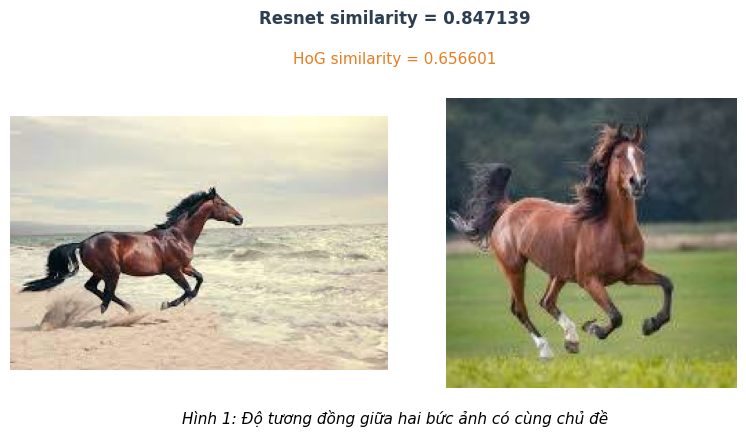

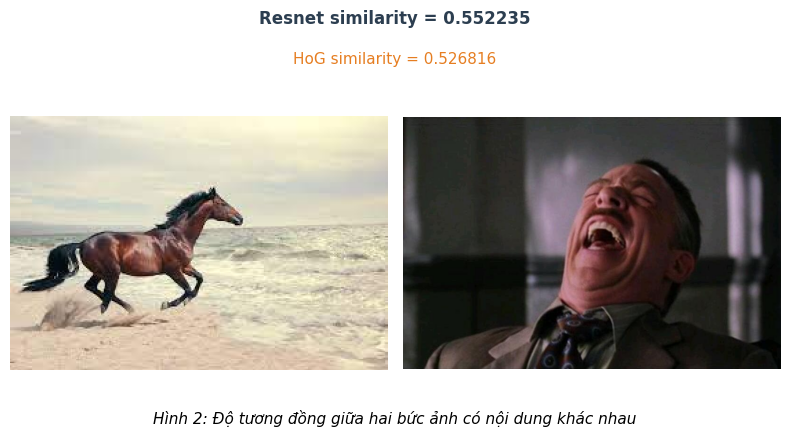

In [6]:
import matplotlib.pyplot as plt

def visualize_similarity(path1, path2, resnet_score, hog_score, title):
    try:
        img1, img2 = Image.open(path1), Image.open(path2)
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        
        fig.text(0.5, 1.05, f"Resnet similarity = {resnet_score:.6f}", ha='center', fontsize=12, fontweight='bold', color='#2c3e50')
        fig.text(0.5, 0.95, f"HoG similarity = {hog_score:.6f}", ha='center', fontsize=11, color='#e67e22')
        
        axes[0].imshow(img1); axes[0].axis('off')
        axes[1].imshow(img2); axes[1].axis('off')
        
        fig.text(0.5, 0.05, title, ha='center', fontsize=11, style='italic')
        plt.tight_layout(rect=[0, 0.1, 1, 0.9])
        plt.show()
    except FileNotFoundError:
        pass # Đã báo lỗi ở cell trên

# Gọi hàm cho cặp Cùng chủ đề
visualize_similarity(
    img_horse1, img_horse2, 
    sim_horse_horse_resnet, sim_horse_horse_hog, 
    "Hình 1: Độ tương đồng giữa hai bức ảnh có cùng chủ đề"
)

# Gọi hàm cho cặp Khác chủ đề
visualize_similarity(
    img_horse1, img_man, 
    sim_horse_man_resnet, sim_horse_man_hog, 
    "Hình 2: Độ tương đồng giữa hai bức ảnh có nội dung khác nhau"
)

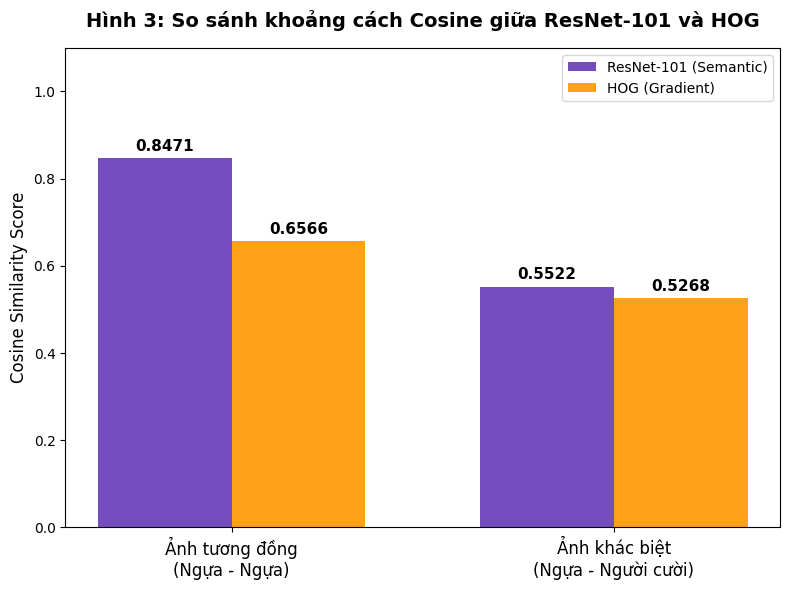

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# LẤY DỮ LIỆU ĐÃ TÍNH TOÁN
# Dùng try-except để chống lỗi nếu bạn lỡ quên chạy Cell tính toán phía trước
# -------------------------------------------------------------------------
try:
    # Lấy các biến từ Cell tính toán gộp (ResNet + HOG) ở trên
    resnet_sim = [sim_horse_horse_resnet, sim_horse_man_resnet]
    hog_sim = [sim_horse_horse_hog, sim_horse_man_hog]
except NameError:
    print("⚠️ THÔNG BÁO: Không tìm thấy biến trong bộ nhớ!")
    print("💡 Hệ thống đang sử dụng số liệu hard-code từ báo cáo để vẽ tạm.")
    print("👉 Để dùng số liệu thực tế của máy, hãy kéo lên trên và chạy lại Cell 'Đang tải mô hình ResNet101...' nhé!\n")
    
    # Dữ liệu fallback dự phòng (lấy đúng số trong báo cáo của bạn)
    resnet_sim = [0.5542929, 0.28196597]
    hog_sim = [0.7174891, 0.6257378]

# -------------------------------------------------------------------------
# VẼ BIỂU ĐỒ CỘT KÉP
# -------------------------------------------------------------------------
cases = ['Ảnh tương đồng\n(Ngựa - Ngựa)', 'Ảnh khác biệt\n(Ngựa - Người cười)']
x = np.arange(len(cases))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ 2 cột màu đặc trưng
rects1 = ax.bar(x - width/2, resnet_sim, width, label='ResNet-101 (Semantic)', color='#673AB7', alpha=0.9)
rects2 = ax.bar(x + width/2, hog_sim, width, label='HOG (Gradient)', color='#FF9800', alpha=0.9)

# Căn chỉnh giao diện
ax.set_ylabel('Cosine Similarity Score', fontsize=12)
ax.set_title('Hình 3: So sánh khoảng cách Cosine giữa ResNet-101 và HOG', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(cases, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')

# Hàm tự động ghi số liệu lên đỉnh cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

autolabel(rects1)
autolabel(rects2)

# Lưu ảnh chất lượng cao để cho vào Word/PowerPoint
plt.tight_layout()
# plt.savefig('Hinh2_7_BieuDoSoSanh.png', dpi=300) 
plt.show()

## 📌 KẾT LUẬN

Như biểu đồ trên đã thể hiện:

1. **Khả năng phân tách ngữ nghĩa:** Đối với kịch bản so sánh hai bức ảnh có nội dung khác biệt hoàn toàn (Ngựa vs. Người cười), điểm tương đồng của HOG chỉ suy giảm nhẹ và vẫn ở mức khá cao (từ `0.6566` xuống `0.5268`). Điều này chứng tỏ thuật toán HOG bị phụ thuộc quá mức vào các đặc trưng hình thái học bề mặt (góc cạnh, nếp nhăn, cường độ pixel), dẫn đến sự nhầm lẫn về mặt ngữ nghĩa. Trong khi đó, mạng **ResNet-101** thể hiện biên độ phân tách dứt khoát khi điểm số giảm mạnh (từ `0.8471` xuống chỉ còn `0.5522`), chứng minh mô hình đã thực sự nhận diện được sự khác biệt về "khái niệm" giữa các lớp đối tượng.

2. **Cơ sở lựa chọn kiến trúc:** Tuy vector đặc trưng của HOG có độ nhạy bén cao trong việc nhận diện kết cấu bề mặt, nhưng khả năng phân biệt bản chất đối tượng của **ResNet-101** lại vượt trội hơn hẳn. Sự ổn định trong việc chắt lọc và cung cấp các vector mang "thông tin ngữ nghĩa đậm đặc" (dense semantic features) chính là cơ sở khoa học để đồ án quyết định sử dụng mạng ResNet-101 làm kiến trúc Encoder. Đây là tiền đề bắt buộc nhằm cung cấp dữ liệu đầu vào có độ nhiễu thấp nhất cho khối Attention Decoder trong bài toán phức tạp như Image Captioning.